## Notebook 03 — Data Profiling & Popularity / Imbalance Bias (MIND-small)

Main questions:
1) **Is there enough political content and political engagement** in the logs to study reinforcement / bias later?
2) **Is the data imbalanced** (popularity concentration / long tail), i.e., do a small number of items dominate exposure and clicks?

### Imports

In [11]:
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

### Path

In [2]:
PROJECT = Path().resolve().parent
DATA = PROJECT / "data"
PROCESSED = DATA / "processed"

print("PROJECT:", PROJECT)
print("PROCESSED exists?", PROCESSED.exists())
print("Files in processed:", [p.name for p in PROCESSED.iterdir()] if PROCESSED.exists() else "MISSING")

PROJECT: C:\Users\jlsmp\Documents\universidade\M.IA\IAS\project
PROCESSED exists? True
Files in processed: ['clicks_dev.pkl', 'clicks_train.pkl', 'news_dev.pkl', 'news_train.pkl']


### Load

Loading the click-level table (clicks_train.pkl) and the article table (news_train.pkl).

- clicks_train: one row per candidate article shown in an impression, with clicked = 0/1.

- news_train: one row per unique news article, with metadata like category/subcategory/title/abstract. - will be used to define grooups like "politics".

In [3]:
clicks = pd.read_pickle(PROCESSED / "clicks_train.pkl")
news = pd.read_pickle(PROCESSED / "news_train.pkl")

print("clicks:", clicks.shape)
print("news:", news.shape)

display(clicks.head(3))
display(news.head(3))


clicks: (5843444, 9)
news: (51282, 8)


,impression_id,user_id,time,history,news_id,clicked,category,subcategory,title
0,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N55689,1,sports,football_nfl,"Charles Rogers, former Michigan State football..."
1,1,U13740,11/11/2019 9:05:58 AM,N55189 N42782 N34694 N45794 N18445 N63302 N104...,N35729,0,news,newsus,Porsche launches into second story of New Jers...
2,2,U91836,11/12/2019 6:11:30 PM,N31739 N6072 N63045 N23979 N35656 N43353 N8129...,N20678,0,sports,more_sports,Bode Miller delivered his twin boys after midw...


,news_id,category,subcategory,title,abstract,url,title_entities,abstract_entities
0,N55528,lifestyle,lifestyleroyals,"The Brands Queen Elizabeth, Prince Charles, an...","Shop the notebooks, jackets, and more that the...",https://assets.msn.com/labs/mind/AAGH0ET.html,"[{""Label"": ""Prince Philip, Duke of Edinburgh"",...",[]
1,N19639,health,weightloss,50 Worst Habits For Belly Fat,These seemingly harmless habits are holding yo...,https://assets.msn.com/labs/mind/AAB19MK.html,"[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik...","[{""Label"": ""Adipose tissue"", ""Type"": ""C"", ""Wik..."
2,N61837,news,newsworld,The Cost of Trump's Aid Freeze in the Trenches...,Lt. Ivan Molchanets peeked over a parapet of s...,https://assets.msn.com/labs/mind/AAJgNsz.html,[],"[{""Label"": ""Ukraine"", ""Type"": ""G"", ""WikidataId..."


### Dataset profiling

In [4]:
total_rows = len(clicks)
total_clicks = int(clicks["clicked"].sum())
ctr = clicks["clicked"].mean()

n_users = clicks["user_id"].nunique()
n_items = clicks["news_id"].nunique()
n_impressions = clicks["impression_id"].nunique()

cands_per_imp = clicks.groupby("impression_id").size()
avg_cands = cands_per_imp.mean()
median_cands = cands_per_imp.median()

summary = pd.DataFrame([{
    "rows (candidates shown)": total_rows,
    "clicks": total_clicks,
    "CTR": ctr,
    "unique users": n_users,
    "unique items": n_items,
    "impressions": n_impressions,
    "avg candidates / impression": avg_cands,
    "median candidates / impression": median_cands,
}])

display(summary)


,rows (candidates shown),clicks,CTR,unique users,unique items,impressions,avg candidates / impression,median candidates / impression
0,5843444,236344,0.040446,50000,20288,156965,37.227688,24.0


- **rows (candidates shown)**: total number of candidate items across all impressions.
  - Each row is a “user saw this candidate article”.

- **clicks**: how many of those candidates were clicked (`clicked=1`).

- **CTR (click-through rate)** = clicks / candidates shown.
  - Example: a CTR of ~0.04 means about **4 clicks per 100 shown candidates**.
  - CTR is typically low in recommender logs - is this a **class imbalance** problem (many 0s, fewer 1s)?

- **impressions**: number of recommendation events (each impression is one list of candidates shown at a time).

- **avg candidates / impression**: average list length (how many candidates were shown each time).

- **median candidates / impression**: the “typical” list length.
  - Median < average usually means there are some impressions with very large candidate lists that pull the average up.

### Politics and measure exposure/click share

MIND does **not** provide an explicit `publisher/source` column, and the provided URLs are Microsoft-hosted pages (not original outlet domains).
So I **cannot** directly group articles by publisher to approximate ideology as I originally intended to do.

Instead, let's start with a simpler grouping that the dataset *does support*:
**politics vs non-politics**, using the `subcategory` field.

Later, if I add left/center/right labels, I will treat them as **proxy labels** inferred from title+abstract and validate them with a small audit.


**What I do here**

1) Mark articles as politics if their `subcategory` contains the string `polit`.
2) Propagate that label to the click-level table (`clicks`) via `news_id`.

**Why this matters**

- If politics is almost absent, a political bias study would be unreliable.
- If politics exists, we can later test reinforcement questions like:
  - Do politically engaged users receive a higher share of political recommendations?
  - Does re-ranking reduce over-concentration while preserving accuracy?


In [5]:
# politics = any subcategory containing "polit" (covers newspolitics, newsworldpolitics, etc.)
news["is_politics"] = news["subcategory"].str.contains("polit", case=False, na=False)

polit_ids = set(news.loc[news["is_politics"], "news_id"])
clicks["is_politics"] = clicks["news_id"].isin(polit_ids)

print("Unique political items:", news["is_politics"].sum())
print("Share of candidates shown that are politics:", clicks["is_politics"].mean())
print("Share of clicks that are politics:", clicks.loc[clicks["clicked"]==1, "is_politics"].mean())
print("Users who clicked politics:", clicks.loc[(clicks["clicked"]==1) & (clicks["is_politics"]), "user_id"].nunique())


Unique political items: 2831
Share of candidates shown that are politics: 0.04470206268768897
Share of clicks that are politics: 0.03825356260366246
Users who clicked politics: 6067


In [6]:
pol_clicks_per_user = (
    clicks.loc[(clicks["clicked"]==1) & (clicks["is_politics"])]
    .groupby("user_id").size()
)

print(pol_clicks_per_user.describe())
print("Users with >= 3 political clicks:", (pol_clicks_per_user >= 3).sum())
print("Users with >= 5 political clicks:", (pol_clicks_per_user >= 5).sum())


count    6067.000000
mean        1.490193
std         1.230731
min         1.000000
25%         1.000000
50%         1.000000
75%         2.000000
max        27.000000
dtype: float64
Users with >= 3 political clicks: 627
Users with >= 5 political clicks: 173


Although many users have too few political clicks to reliably estimate user-level political preferences, the dataset still contains a substantial politically engaged subset (n=627 with ≥3 political clicks) and enough political content to support the intended analysis.

### Politics vs non-politics: CTR comparison

Comparing CTR (click rate) for political vs non-political candidates.

- is political content clicked more/less than other content?

- is it over/under represented in exposure?

Lets check how often politics items appear as candidates (exposure), how often they receive clicks, and how likely they are to be clicked when shown (CTR).

To better understand: 
- **Exposure share**: fraction of all candidate rows that are politics vs non-politics.
- **Click share**: fraction of all clicks that go to politics vs non-politics.
- **CTR**: click probability given exposure.


In [7]:
group_ctr = clicks.groupby("is_politics")["clicked"].mean().rename(index={False:"non-politics", True:"politics"})
group_exposure = clicks["is_politics"].value_counts(normalize=True).rename(index={False:"non-politics", True:"politics"})
group_clickshare = clicks.loc[clicks["clicked"]==1, "is_politics"].value_counts(normalize=True).rename(index={False:"non-politics", True:"politics"})

display(pd.DataFrame({
    "exposure share": group_exposure,
    "click share": group_clickshare,
    "CTR": group_ctr
}))


,exposure share,click share,CTR
is_politics,,,
non-politics,0.955298,0.961746,0.040719
politics,0.044702,0.038254,0.034611


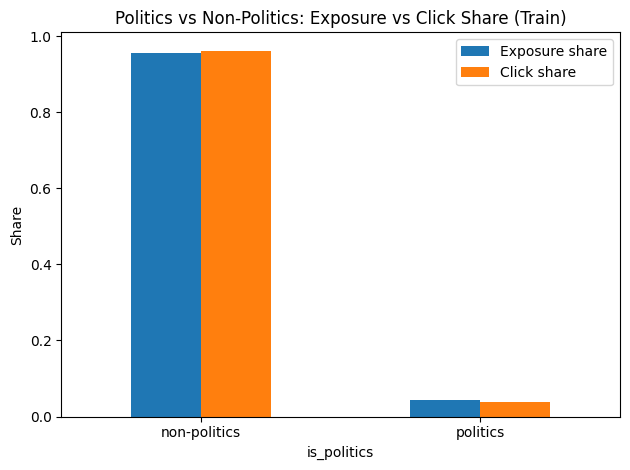

In [8]:
plot_df = pd.DataFrame({
    "Exposure share": group_exposure,
    "Click share": group_clickshare
})

ax = plot_df.plot(kind="bar", rot=0)
ax.set_ylabel("Share")
ax.set_title("Politics vs Non-Politics: Exposure vs Click Share (Train)")
plt.tight_layout()
plt.show()


In the training logs, political content represents a small but measurable fraction of exposures (~4.5%) and receives a slightly smaller fraction of clicks (~3.8%). Political candidates also have a lower CTR (3.46%) than non-political candidates (4.07%). This indicates that, on average, political items are less likely to be clicked when shown.

### Exposure and click concentration

Recommendation logs might have a **long-tail** structure:
- a small number of “head” items get shown/clicked a lot
- many items are rarely shown

Lets quantify this with:
- **Top X% share**: how much exposure/clicks are captured by the most-exposed items (X = 1%, 5%, 10%)
- **Gini coefficient**: a single number summarizing inequality (0 = equal, 1 = highly unequal)


In [9]:
# Exposure = how often an item is shown as a candidate
exposure = clicks["news_id"].value_counts()

# Clicks per item
item_clicks = clicks.groupby("news_id")["clicked"].sum()

stats = pd.DataFrame({
    "exposure": exposure,
    "clicks": item_clicks
}).fillna(0)

stats = stats.sort_values("exposure", ascending=False)

def top_share(series, pct):
    cutoff = max(1, int(len(series) * pct))
    return float(series.iloc[:cutoff].sum() / series.sum())

for pct in [0.01, 0.05, 0.10]:
    print(f"Top {int(pct*100)}% items capture exposure share: {top_share(stats['exposure'], pct):.3f}")
    print(f"Top {int(pct*100)}% items capture click share:     {top_share(stats['clicks'], pct):.3f}")
    print("---")


Top 1% items capture exposure share: 0.324
Top 1% items capture click share:     0.475
---
Top 5% items capture exposure share: 0.741
Top 5% items capture click share:     0.794
---
Top 10% items capture exposure share: 0.905
Top 10% items capture click share:     0.917
---


The interaction logs exhibit strong popularity concentration. The top 1% most-exposed items account for 32.4% of all exposures and 47.5% of all clicks, while the top 10% account for over 90% of both exposure and clicks. This indicates a pronounced head–tail imbalance and motivates re-ranking/mitigation methods aimed at reducing over-concentration while monitoring potential losses in recommendation accuracy.

In [12]:
def gini(x):
    x = np.array(x, dtype=float)
    if np.all(x == 0):
        return 0.0
    x = np.sort(x)
    n = len(x)
    cumx = np.cumsum(x)
    return (n + 1 - 2 * np.sum(cumx) / cumx[-1]) / n

print("Gini exposure:", gini(stats["exposure"].values))
print("Gini clicks:", gini(stats["clicks"].values))


Gini exposure: 0.9157078050681056
Gini clicks: 0.9440959180623048


Both exposure and clicks show extreme inequality across items (Gini exposure = 0.916; Gini clicks = 0.944), indicating a strong head-tail imbalance where a small fraction of items dominates user attention. This motivates re-ranking strategies to reduce over-concentration and evaluate the accuracy-diversity trade-off.